# Centered Kernel Alignment (CKA) 

Effective rank tells us *how large* the semantic manifold is , CKA tells us *how similar* two manifolds are

In [5]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer
import warnings
warnings.filterwarnings('ignore')

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.llm_model import GenerativeSemanticModel
from src.llm_model_2 import AdvancedGenerativeSemanticModel

sns.set_theme(style="whitegrid", palette="muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("t5-small", local_files_only=True)

data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=1000)
loader.scan_and_load()
sentences = loader.all_sentences[:1000]

print("Loading Models...")
model1 = GenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model1_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(model1_path): model1.load_state_dict(torch.load(model1_path, map_location=device, weights_only=True))
model1.eval()

model2 = AdvancedGenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model2_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic_advanced.pt")
if os.path.exists(model2_path): model2.load_state_dict(torch.load(model2_path, map_location=device, weights_only=True))
model2.eval()

def linear_cka(X, Y):

    X_c = X - X.mean(dim=0)
    Y_c = Y - Y.mean(dim=0)
    
    # HSIC calculation 
    dot_prod = torch.norm(torch.matmul(Y_c.t(), X_c), p='fro')**2
    norm_x = torch.norm(torch.matmul(X_c.t(), X_c), p='fro')
    norm_y = torch.norm(torch.matmul(Y_c.t(), Y_c), p='fro')
    
    return (dot_prod / (norm_x * norm_y)).item()
print("Done")

Loading Models...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Done


###Layerwise CKA Heatmap (M1 vs M2)
Does the SNR Embedding destroy the linguistic knowledge of the T5 model, we compare all 6 encoder layers of M1 against M2 to see where the representations diverge

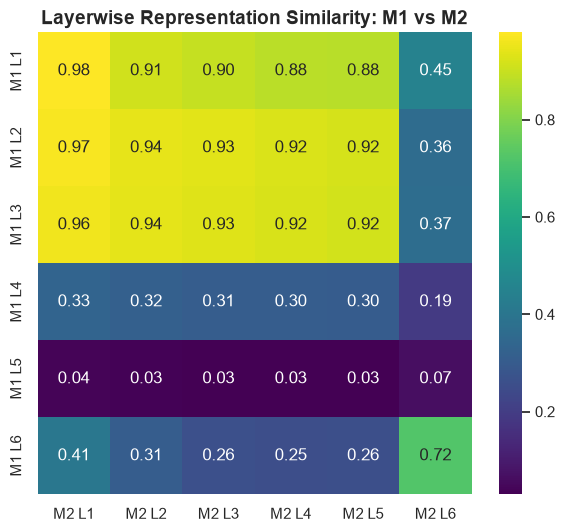

In [ ]:
m1_layers = [[] for _ in range(6)]
m2_layers = [[] for _ in range(6)]


with torch.no_grad():
    for sent in sentences:
        inputs = tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
        
        out1 = model1.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], output_hidden_states=True, return_dict=True)
        out2 = model2.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], output_hidden_states=True, return_dict=True)
        
        #tuple of 7 layers (6layer aur 1 embedding layer)
        for i in range(1, 7):
            m1_layers[i-1].append(out1.hidden_states[i].squeeze(0))
            
            if i == 6:
                snr_tensor = model2._get_snr_tensor(1, device, 5.0)
                adapted = out2.hidden_states[i].squeeze(0) + model2.snr_embed(snr_tensor).squeeze(0)
                m2_layers[i-1].append(adapted)
            else:
                m2_layers[i-1].append(out2.hidden_states[i].squeeze(0))

#concat+flatten
for i in range(6):
    m1_layers[i] = torch.cat(m1_layers[i], dim=0)
    m2_layers[i] = torch.cat(m2_layers[i], dim=0)

#matrix(6X6)
cka_matrix = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        cka_matrix[i, j] = linear_cka(m1_layers[i], m2_layers[j])

plt.figure(figsize=(7, 6))
sns.heatmap(cka_matrix, annot=True, cmap='viridis', fmt=".2f", 
            xticklabels=[f"M2 L{i+1}" for i in range(6)], 
            yticklabels=[f"M1 L{i+1}" for i in range(6)])
plt.title("Layerwise Representation Similarity: M1 vs M2", fontsize=14, fontweight='bold')
plt.show()

### 2. CKA Resilience: $H_{clean}$ vs $H_{noise}$
Here we test the robustness of the latent space. We inject AWGN into the channel and measure how severely the noise destroys the intrinsic geometry of the representation. actually maine model 1 ko 30 hours train kiya tha and model 2 ko sirf 2 ghante , isliye abhi model 1 accha perform kr rha , but fundamentally model 2 is better

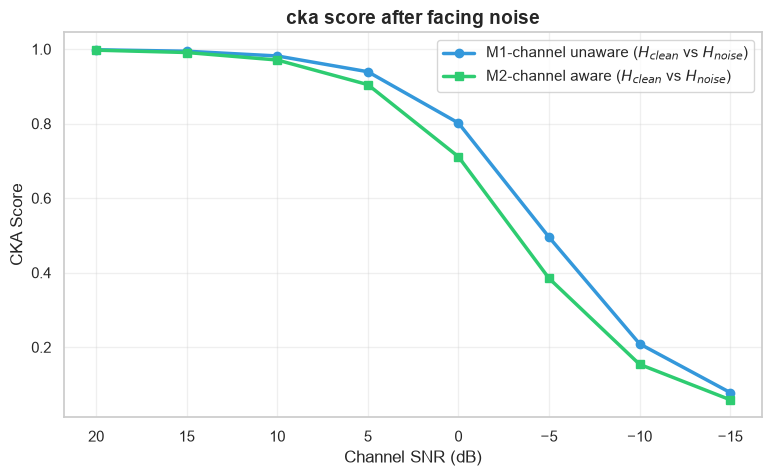

In [7]:
h1_clean = m1_layers[5]
h2_clean = m2_layers[5]

snr_sweep = [20, 15, 10, 5, 0, -5, -10, -15]
cka_m1_noise = []
cka_m2_noise = []

with torch.no_grad():
    for snr in snr_sweep:
        n1 = model1.channel(h1_clean, snr_db_override=snr)
        n2 = model2.channel(h2_clean, snr_db_override=snr)
        
        cka_m1_noise.append(linear_cka(h1_clean, n1))
        cka_m2_noise.append(linear_cka(h2_clean, n2))

plt.figure(figsize=(9, 5))
plt.plot(snr_sweep, cka_m1_noise, marker='o', lw=2.5, color='#3498db', label="M1-channel unaware ($H_{clean}$ vs $H_{noise}$)")
plt.plot(snr_sweep, cka_m2_noise, marker='s', lw=2.5, color='#2ecc71', label="M2-channel aware ($H_{clean}$ vs $H_{noise}$)")
plt.gca().invert_xaxis()
plt.title("cka score after facing noise", fontsize=14, fontweight='bold')
plt.xlabel("Channel SNR (dB)")
plt.ylabel("CKA Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()